In [1]:
seed = 4
vae_scaling_kl = 0.01
loo = True
mod_type = 'default'

In [2]:
subset = False
short_run = False

In [3]:
n_fraction = 0.2

train_frac, test_frac = 0.8, 0.2

a_scale = 10
b_scale = 2

if mod_type not in ['default', 'tot_bias_scaler', 'global_bias_scaler', 'mu_bias_scaler', 
                   'global_bias_regularizer', 'mu_bias_regularizer', 
                   'standardized_weights']:
    raise ValueError('Incorrect mod type specified')

# assign file name accordingly

fn = 'consistency_tests_seed_' + str(seed) + '_vaescalingKL_' + str(vae_scaling_kl).replace('.', '_')
fn += mod_type
if mod_type == 'tot_bias_scaler':
    fn += '_tot_a' + str(a_scale) + '_b' + str(b_scale)
elif mod_type == 'global_bias_scaler':
    fn += '_global_a' + str(a_scale) + '_b' + str(b_scale)
elif mod_type == 'mu_bias_scaler':
    fn += '_mu_a' + str(a_scale) + '_b' + str(b_scale)
if subset:
    fn += '_subset'
if short_run:
    fn += '_short_run'
if loo:
    fn += '_loo'

In [4]:
import os
from typing import Optional, Dict, List, Literal
import copy
import itertools
from tqdm import tqdm

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.metrics import normalized_mutual_info_score
import torch
import scanpy as sc
import pandas as pd
from typing import List, Literal
import torch
from geomloss import SamplesLoss
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [5]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

from scLEMBAS.model.train_dev_mu_regularizer import TrainSC as TrainSCDevMu
from scLEMBAS.model.train_dev_weights_standard import TrainSC as TrainSCDevWstandard
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, embed_tf_activity, get_alignment_score


from scLEMBAS.model.scl_dev_tot_scaler import SignalingModel as SignalingModelDevTot
from scLEMBAS.model.scl_dev_global_scaler import SignalingModel as SignalingModelDevGlobal
from scLEMBAS.model.scl_dev_mu_scaler import SignalingModel as SignalingModelDevMu
from scLEMBAS.model.scl_dev_weights_standard import SignalingModel as SignalingModelDevWstandard
from scLEMBAS.model.scl import SignalingModel

SM = {'default': SignalingModel, 
     'tot_bias_scaler': SignalingModelDevTot, 
     'global_bias_scaler': SignalingModelDevGlobal, 
     'mu_bias_scaler': SignalingModelDevMu, 
     'global_bias_regularizer': SignalingModel, 
     'mu_bias_regularizer': SignalingModel,
     'standardized_weights': SignalingModelDevWstandard # initializes weights much larger
     }

TR = {'default': TrainSC, 
     'tot_bias_scaler': TrainSC, 
     'global_bias_scaler': TrainSC, 
     'mu_bias_scaler': TrainSC, 
     'global_bias_regularizer': TrainSC, # by default, regularizes global bias
      'mu_bias_regularizer': TrainSCDevMu, 
      'standardized_weights': TrainSCDevWstandard 
     }

sys.path.insert(1, '/home/hmbaghda/Projects/scLEMBAS/notebooks/Kang_2017/')
from Kang_utils import (rev_stim, stim_map, rev_stim_map, adata_dimviz_bias, 
                        get_prediction, adata_dimviz_prediction, prepare_for_metrics)

In [6]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Create a novel train-test split:

In [8]:
def ood_split(tf_adata, 
             train_frac: float, 
              stim_col: str = 'stim', 
              context_col: str = 'seurat_annotations', 
              context_bins: Optional[pd.DataFrame] = None, 
              context_bins_frac: float = 1, 
             max_iter: int = 1000, 
             seed: int = 888, 
             deviation_thresh: float = 0.025, 
             include_train_cond: Optional[Dict[str, List]] = None):
    """Generate an OOD train test split, where both the condition data and the single-cells have approximately
    the specified split.
    
    Rules: 
    1. cell split and condition split is similar (conditions is exactly the split, 
    cells is approximate by deviation_thresh)
    2. Each component (condition_cols) of the condition is seen atleast once in the training
    3. Each of the stimulation column is seen atleast once in the test
    4. The test context (cell type) needs to contain atleast one from context_frac of the total context_bins 

    Parameters
    ----------
    tf_adata : 
        AnnData object of TF activity
    train_frac : float
        the fraction of the data going to training
    stim_col : List[str]
        the metadata column defining the stimulation condition
    context_col: str
        the metadata column of the context, together with stim col defines the OOD split
    context_bins: Optional[pd.DataFrame]
        binning of the context categories, by default None
    context_bins_frac: float
        the number of bins that should be included in the test data from the context bins
    max_iter : int, optional
        total iterations to try to identify a suitable split, by default 1000
    seed : int, optional
        random state variable, by default 888
    deviation_thresh : float, optional
        extent to which to allow the single-cell split to deviate from the specified `train_frac split`, by default 0.025
    include_train_cond : Optional[Dict[str, List]]
        a dictionary with keys for each of stim_col and context_col and keys as a list that represents a subset
        of values in that column that must be included in the training set. 
    """
    test_frac = 1 - train_frac

    condition_cols = [stim_col, context_col]
    condition_combs = tf_adata.obs[condition_cols].apply(lambda row: '^'.join(row.astype(str)), axis=1)
    unique_conditions = condition_combs.drop_duplicates(keep = 'first', inplace = False).tolist()

    # define the conditions for stopping
    train_frac_deviation = np.inf
    zero_shot_bool = False

    test_stim = False
    n_stims = tf_adata.obs['stim'].nunique()

    if context_bins is not None:
        if context_bins_frac > 1 or context_bins_frac < 0:
            raise ValueError('The fraction must be between 0 and 1')
        n_contexts = np.floor(context_bins_frac*context_bins.nunique())
        context_present = False
    else:
        context_present = True

    if include_train_cond is not None:
        if sorted(set(include_train_cond).intersection(condition_cols)) != sorted(condition_cols):
            raise ValueError('Keys for `include_train_cond` must be the same as `condition_cols`')
        for cond, cond_vals in include_train_cond.items():
            if not set(cond_vals).issubset(tf_adata.obs[cond].tolist()):
                raise ValueError('The conditions to include in training for ' + cond + ' are not present in the metadata.')
        ict_bool = False
    else:
        ict_bool = True

    counter = 0
    while (train_frac_deviation > deviation_thresh or not zero_shot_bool or not ict_bool or not test_stim or not context_present) and (counter < max_iter):
        # ood at categorical level
        train_cond, test_cond = train_test_split(unique_conditions, test_size = test_frac, random_state = seed + counter, shuffle = True)
        train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
        test_cells = condition_combs[condition_combs.isin(test_cond)].index.tolist()

        train_frac_actual = len(train_cells)/tf_adata.shape[0]
        train_frac_deviation = abs(train_frac_actual - train_frac)

        # ensure that all individual conditions are seen atleast once (it's the combination of conditions that's unique)
        train_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

        test_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

        zero_shots = [len(test_cond_map[cond].difference(train_cond_map[cond])) for cond in condition_cols]    
        zero_shot_bool = all(value == 0 for value in zero_shots)

        test_stim = (len(test_cond_map['stim']) == n_stims)


        if context_bins is not None:
            context_present = context_bins.loc[list(test_cond_map[context_col])].nunique() >= n_contexts

        if include_train_cond is not None:
            ict_conds = [len(include_train_cond[cond].difference(cond_vals)) for cond, cond_vals in train_cond_map.items()]
            ict_bool = any(value == 0 for value in ict_conds)

        counter += 1

    if counter < max_iter:
        return train_cells, test_cells, train_cond, test_cond
    else:
        return None, None, None, None

In [9]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table = contingency_table.T.sort_values(by = 'Total').T
bins = pd.qcut(contingency_table.T.Total, q = 4, labels = False)

In [10]:
if not loo:
    condition_cols = ['stim', 'seurat_annotations']
    train_cells, test_cells, train_cond, test_cond = ood_split(tf_adata,
                                                                       train_frac = 0.8,
                                                                       stim_col = condition_cols[0], 
                                                                       context_col = condition_cols[1], 
                                                                       context_bins = bins, 
                                                                       context_bins_frac = 1, 
                                                                       max_iter = 1000, 
                                                                       seed = seed, 
                                                                       deviation_thresh = 0.025, 
                                                                       include_train_cond = None)

    test_conds = test_cond
else:
    unique_conditions = sorted(set(tf_adata.obs.condition))

    unique_conditions.remove('CTRL^DC')
    unique_conditions.insert(0, 'CTRL^DC')
    
    test_cond = [unique_conditions[0]]
    train_cond = sorted(set(unique_conditions).difference(test_cond))
    
    test_conds = test_cond
    
    test_cells = tf_adata.obs[tf_adata.obs.condition.isin(test_cond)].index.tolist()
    train_cells = tf_adata.obs[tf_adata.obs.condition.isin(train_cond)].index.tolist()

In [11]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
CTRL^Eryth             23
STIM^Eryth             32
CTRL^pDC               51
STIM^pDC               81
CTRL^Mk               115
STIM^Mk               121
CTRL^B Activated      185
STIM^B Activated      203
STIM^DC               214
CTRL^NK               298
CTRL^T activated      300
STIM^NK               321
STIM^T activated      333
CTRL^CD8 T            352
CTRL^B                407
STIM^CD8 T            462
CTRL^CD16 Mono        507
STIM^CD16 Mono        537
STIM^B                571
CTRL^CD4 Memory T     859
STIM^CD4 Memory T     903
CTRL^CD4 Naive T      978
STIM^CD4 Naive T     1526
STIM^CD14 Mono       2147
CTRL^CD14 Mono       2215
Name: count, dtype: int64

In [12]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
CTRL^DC    258
Name: count, dtype: int64

# 2. Subset data

In [13]:
if subset:
    tf_adata_all = tf_adata.copy()
    train_cells_all = copy.deepcopy(train_cells)

    tf_adata_train = tf_adata_all[train_cells_all, :]
    condition_proportions = tf_adata_train.obs['condition'].value_counts(normalize=True)
    total_cells = tf_adata_train.n_obs
    n_subset = int(n_fraction * total_cells)

    # number of cells to sample per condition
    sample_sizes = (condition_proportions * n_subset).round().astype(int)

    # Subset the cells for each condition
    subset_indices = []
    for condition, n_cells in sample_sizes.items():
        condition_indices = tf_adata_train.obs[tf_adata_train.obs['condition'] == condition].index
        np.random.seed(seed)
        sampled_condition_indices = np.random.choice(condition_indices, size=n_cells, replace=False)
        subset_indices.extend(sampled_condition_indices)

    n_train = len(subset_indices)
    train_cells = copy.deepcopy(subset_indices)
    print('The number of train cells has been reduced from {} to {}'.format(tf_adata_train.shape[0], 
                                                                           n_train))

    # include the test data
    subset_indices.extend(test_cells)
    tf_adata = tf_adata_all[subset_indices,:]
else:
    train_cels_all = train_cells

In [14]:
tf_adata

View of AnnData object with n_obs × n_vars = 13999 × 240
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'n_genes', 'gene_clusters', 'TF_clusters', 'condition'
    uns: 'TF_clusters_colors', 'leiden', 'neighbors', 'pca', 'seurat_annotations_colors', 'stim_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [15]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
CTRL^Eryth             23
STIM^Eryth             32
CTRL^pDC               51
STIM^pDC               81
CTRL^Mk               115
STIM^Mk               121
CTRL^B Activated      185
STIM^B Activated      203
STIM^DC               214
CTRL^NK               298
CTRL^T activated      300
STIM^NK               321
STIM^T activated      333
CTRL^CD8 T            352
CTRL^B                407
STIM^CD8 T            462
CTRL^CD16 Mono        507
STIM^CD16 Mono        537
STIM^B                571
CTRL^CD4 Memory T     859
STIM^CD4 Memory T     903
CTRL^CD4 Naive T      978
STIM^CD4 Naive T     1526
STIM^CD14 Mono       2147
CTRL^CD14 Mono       2215
Name: count, dtype: int64

In [16]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
CTRL^DC    258
Name: count, dtype: int64

# 3. Run training

In [17]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor = 10, lr_decay = 0.9):
    lr_period = 3 if n_epochs < 500 else 4
    lr_params = {'max_epochs': n_epochs, 
                 'maximum_learning_rate': max_lr, 
                 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(n_epochs/lr_period), 
                 'reset_optimizer_epoch': int(n_epochs/3), 
                'lr_decay': lr_decay, 
                 'lr_restart_factor': 1, 
                 'warmup_epochs': int(n_epochs/10)}
    return lr_params

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  lr_scaling_factor = 10, lr_decay = 0.9):
    general_params = generate_lr_params(n_epochs, max_lr, lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay)
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'reset_optimizer_epoch']
    discriminator_params = {'batch_momentum': 0.01,
                            'layer_norm': False,
                            'dropout_rate': 0.1,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [18]:
# hyperparameters
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# linear scaling of inputs/outputs
projection_amplitude_in = 10
projection_amplitude_out = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2}
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}


if mod_type in ['default', 'total_bias_scaler', 'mu_bias_regularizer', 'mu_bias_scaler']: 
    bionet_params['cat_max_norm'] = 100
elif mod_type in ['global_bias_scaler', 'global_bias_regularizer']:
    bionet_params['cat_max_norm'] = 50 # since scaling global bias, need to separately scale categorical with the regularization

    
if mod_type in ['tot_bias_scaler', 'global_bias_scaler', 'mu_bias_scaler']:
    bionet_params['signaling_weights_scaler'] = a_scale
    if mod_type == 'tot_bias_scaler':
        bionet_params['bias_tot_scaler'] = b_scale
    elif mod_type == 'global_bias_scaler':
        bionet_params['bias_global_scaler'] = b_scale
    elif mod_type == 'mu_bias_scaler':
        bionet_params['bias_mu_scaler'] = b_scale

In [19]:
# training parameters
other_params_default = {'network_noise_scale': 10, 'gradient_noise_scale': 1e-9, 
               'test_batch_size': np.nan}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, #50, 
                          'subset_n_spectral': 5} #10}

if mod_type != 'standardized_weights':
    target_spectral_radius = 0.9
else: 
    target_spectral_radius = 30

regularization_params_default = {'input_lambda_L2': 0, # doesn't matter if setting the requires grad to False
                         'bn_weights_lambda_l2': 1e-7, 
                         'bn_bias_lambda_L2': 0, # don't incorporate because of KL divergence
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e2,  
                         'uniform_lambda_L2': 1e-7,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 1e-7, 
                        'vae_scaling_KL': vae_scaling_kl}


if mod_type.endswith('_regularizer'):
    regularization_params_default['bn_weights_lambda_l2'] = 1e-12 # decrease adj matrix regularization
    regularization_params_default['bn_bias_lambda_L2'] = 1e-5 # increase global bias regularization

In [20]:
if not short_run:
    max_penalty_weight = 7.75
    b = 0.6
    max_epochs = 600
else:
    max_penalty_weight = 8
    b = 1
    max_epochs = 250 
    
    
if subset:
    batch_factor = 1 if n_fraction <= 0.2 else 3
    train_batch = int(np.round(n_train/batch_factor))
else:
    train_batch = 1024


max_lr = 0.001



discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                          min_penalty_weight = 0.1,
                                                          max_penalty_weight = max_penalty_weight,
                                                          a = 1,
                                                          b = b, 
                                                          curve_type = 'power')


lr_params = generate_lr_params(n_epochs = max_epochs, max_lr = max_lr, lr_scaling_factor = 10, lr_decay = 0.9)
discriminator_params = generate_discriminator_params(n_epochs = max_epochs, max_lr = max_lr, 
                      discriminator_penalty_weight = discriminator_penalty_weight, 
                      lr_scaling_factor = 10, lr_decay = 0.9)

regularization_params = regularization_params_default.copy()
other_params = {**other_params_default,
                **{'train_batch_size': train_batch,
                   'validation_batch_size': np.nan}}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}


<Axes: >

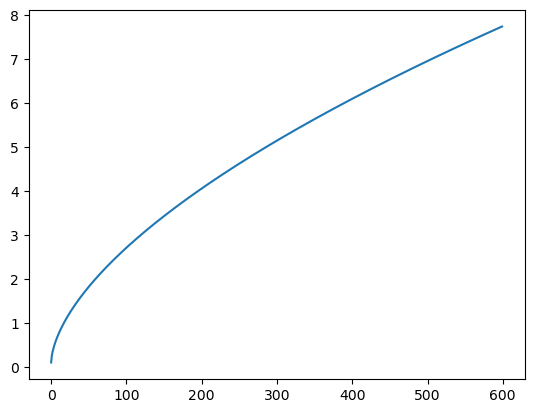

In [21]:
sns.lineplot(discriminator_penalty_weight)

# Checkpoint: load the object

In [22]:
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_trainer.pickle'))
mod = trainer.mod

test_cells = trainer.X_test.index.tolist()
train_cells = trainer.X_train.index.tolist()

train_cond = sorted(tf_adata[train_cells, :].obs.condition.unique())
test_cond = sorted(tf_adata[test_cells, :].obs.condition.unique())
test_conds = test_cond

train_cells_all = train_cells

In [23]:
if torch.isinf(mod.signaling_network.weights).any():
    raise ValueError('Exploding gradients')

# 4. Look at the loss curves:

In [24]:
train_stats_df = trainer.stats['train'].copy()
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

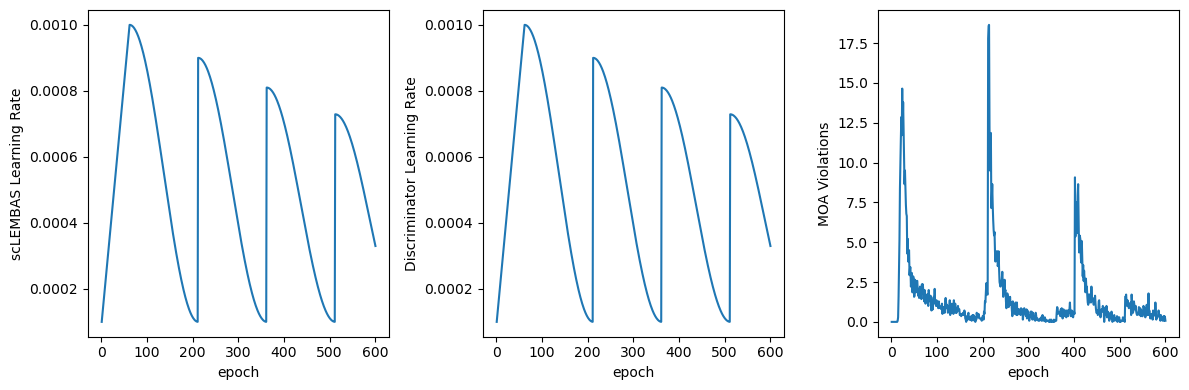

In [25]:
fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
ax[1].set_ylabel('Discriminator Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[2])
ax[2].set_ylabel('MOA Violations')

fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_epochs' + '.png'), dpi=300, bbox_inches='tight')


/tmp/ipykernel_1970315/2785014357.py:32: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)


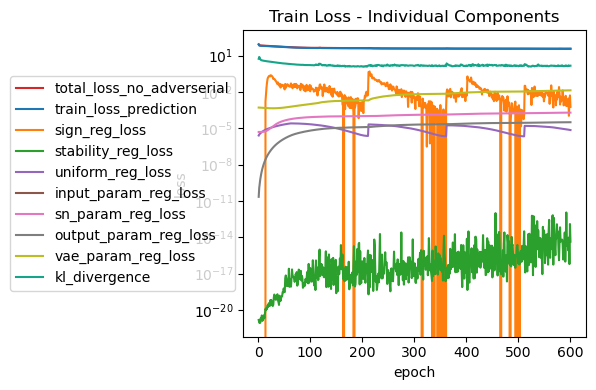

In [26]:
fig, ax = plt.subplots(ncols = 1, figsize = (8, 4))

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']


viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)
# ax.set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax.set_title('Train Loss - Individual Components')
ax.set_yscale('log')

fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_all' + '.png'), dpi=300, bbox_inches='tight')



# 5. Bias Adverserial Assessment

/tmp/ipykernel_1970315/2186760741.py:34: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_1970315/2186760741.py:47: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[1])


''

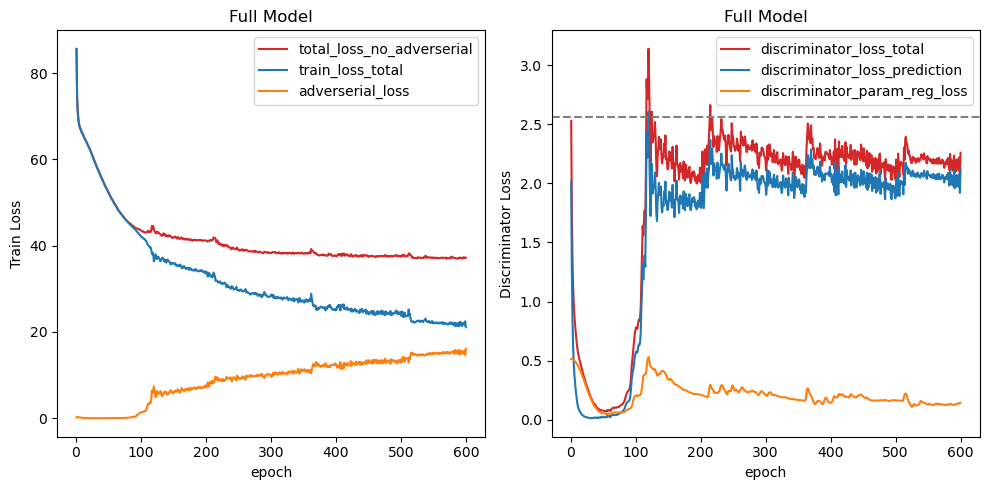

In [27]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[1])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[1].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[1].legend(loc='best')
ax[1].set_ylabel('Discriminator Loss')
ax[1].set_title('Full Model')


fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_adverserial' + '.png'), dpi=300, bbox_inches='tight')
;



In [28]:
cf_map = {'in_distribution': train_cells}
counterfactual_types = list(cf_map.keys()) + ['opposite']

In [29]:
biases_res = {}
for counterfactual_type in ['opposite']:#, 'in_distribution']:
    biases_res[counterfactual_type] = {}
    biases = get_prediction(mod = mod, 
                                                 tf_adata = tf_adata, 
                                                 counterfactual_type = counterfactual_type, 
                                                 cf_map = cf_map, 
                                                 train_cells_all = train_cells, 
                                                 test_conds = test_conds, 
                                                 return_bias = True)
    bias_global, bias_mu, bias_sigma, bias_cats, bias_tot, obs = biases
    
    biases_res[counterfactual_type]['adverserial'] = (bias_global, bias_mu, bias_sigma, bias_cats, bias_tot)
    biases_res[counterfactual_type]['obs'] = obs
    del biases
    torch.cuda.empty_cache()

''

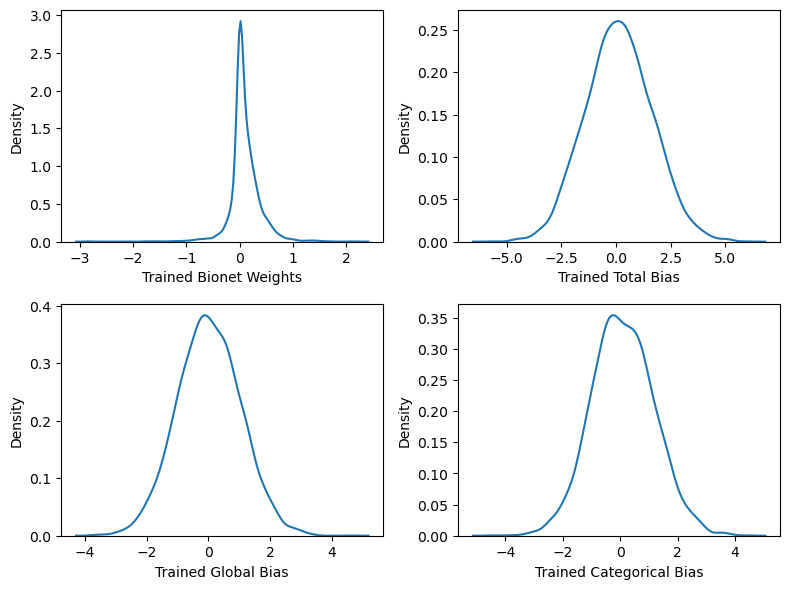

In [30]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (8, 6))
ax = axes.flatten()

np.random.seed(seed)

weights = mod.signaling_network.weights.detach().cpu().numpy().flatten()
if 'signaling_weights_scaler' in mod.signaling_network.bionet_params:
    weights *= mod.signaling_network.bionet_params['signaling_weights_scaler']
sns.kdeplot(np.random.choice(weights[weights!=0], 5000, replace = False), ax = ax[0])
ax[0].set_xlabel('Trained Bionet Weights')

bias = bias_tot.detach().cpu().numpy().flatten()
sns.kdeplot(np.random.choice(bias, 5000, replace = False), ax = ax[1])
ax[1].set_xlabel('Trained Total Bias')

bias = bias_global.detach().cpu().numpy().flatten()
sns.kdeplot(np.random.choice(bias, 5000, replace = False), ax = ax[2])
ax[2].set_xlabel('Trained Global Bias')

# bias = bias_cats.detach().cpu().numpy().flatten()
sns.kdeplot(bias_cats.detach().cpu().numpy()[:,1], ax = ax[3])
ax[3].set_xlabel('Trained Categorical Bias')

fig.tight_layout()
plt.savefig(os.path.join(data_path, 'trash', fn + '_bias_dist' + '.png'), dpi=300, bbox_inches='tight')
;

Run the embedding:

In [31]:
biases_clustered = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_feb_clustered_biases.pickle'))

''

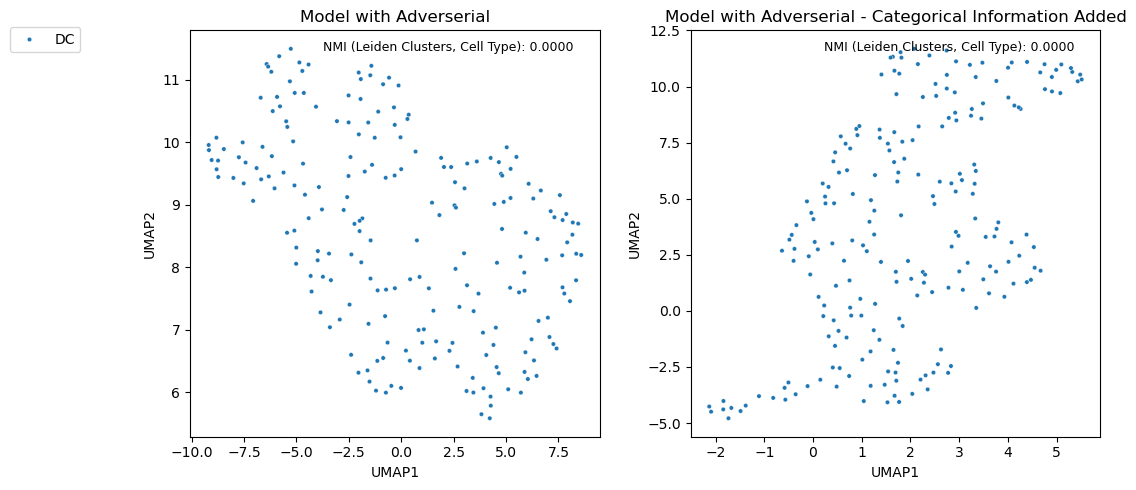

In [32]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
ax = ax.flatten()

counterfactual_type = 'opposite'
bias_global, bias_tot, _ = biases_clustered[counterfactual_type]
adata_types = ['Model with Adverserial', 'Model with Adverserial - Categorical Information Added']
adata_dict = dict(zip(adata_types, 
                     [bias_global,bias_tot]))


subset_size = None
for i, (adata_type, adata) in enumerate(adata_dict.items()):
    if adata is not None:
        viz_df, nmi = adata_dimviz_bias(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                             subset_size = subset_size)
        

        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                        s=10,
                        ax = ax[i])
        ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i].set_title(adata_type)
    else:
        ax[i].axis('off')

lines, labels = ax[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_bias_adverserial' + '.png'), dpi=300, bbox_inches='tight')

;


# 6. Get the test predictions

In [33]:
best_resolution = tf_adata.uns['leiden']['params']['resolution']
calculation_type = 'project' # project data rather than embed
n_neighbors = 15
run_umap = True

In [34]:
cf_map = {'in_distribution': train_cells}
counterfactual_types = list(cf_map.keys()) + ['opposite']

counterfactual_type = 'opposite'

In [35]:
tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
loss_res = pd.read_csv(os.path.join(data_path, 'trash', fn + '_predictions_loss.csv'), 
                      index_col = 0)


# 7. Visualize Predictions

# 7.1 Visualize loss of each component:

/tmp/ipykernel_1970315/630925757.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


''

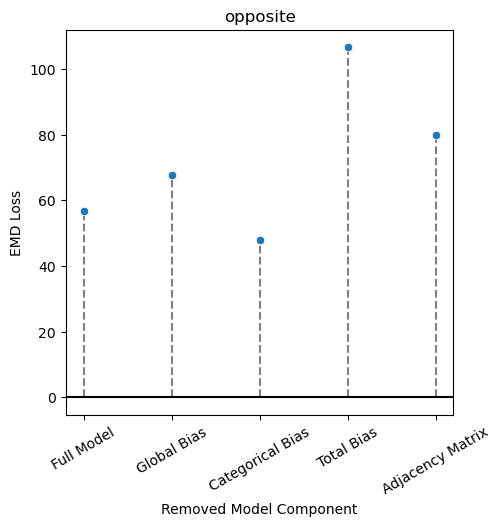

In [36]:
fig, ax = plt.subplots(ncols = 1, figsize = (5, 5))


xtick_map = {'none': 'Full Model', 
 'adj': 'Adjacency Matrix', 
 'total_bias': 'Total Bias', 
'categorical_bias': 'Categorical Bias', 
'global_bias': 'Global Bias'}


viz_df = loss_res.reset_index().rename(columns = {'index': 'Removed Model Component'})
viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)

sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = 'EMD Loss', ax = ax)

for x, y in zip(viz_df['Removed Model Component'], viz_df['EMD Loss']):
    ax.vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
ax.axhline(y=0, color='black')

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')

ax.set_title(counterfactual_type)
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_components' + '.png'), dpi=300, bbox_inches='tight')

;


## 7.2 Visualize first 2 PCs of each model component

In [37]:
tf_res_ = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))

In [38]:
remove_components = ['none', 'global_bias', 'categorical_bias', 'total_bias', 'adj']
cell_types = [tc.split('^')[1] for tc in test_conds]
nrows = max(2, len(test_conds))
ncols = len(remove_components)

counterfactual_type = 'opposite'

/tmp/ipykernel_1970315/2868866222.py:62: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  fig.legend(handles=legend_actual.legendHandles,


''

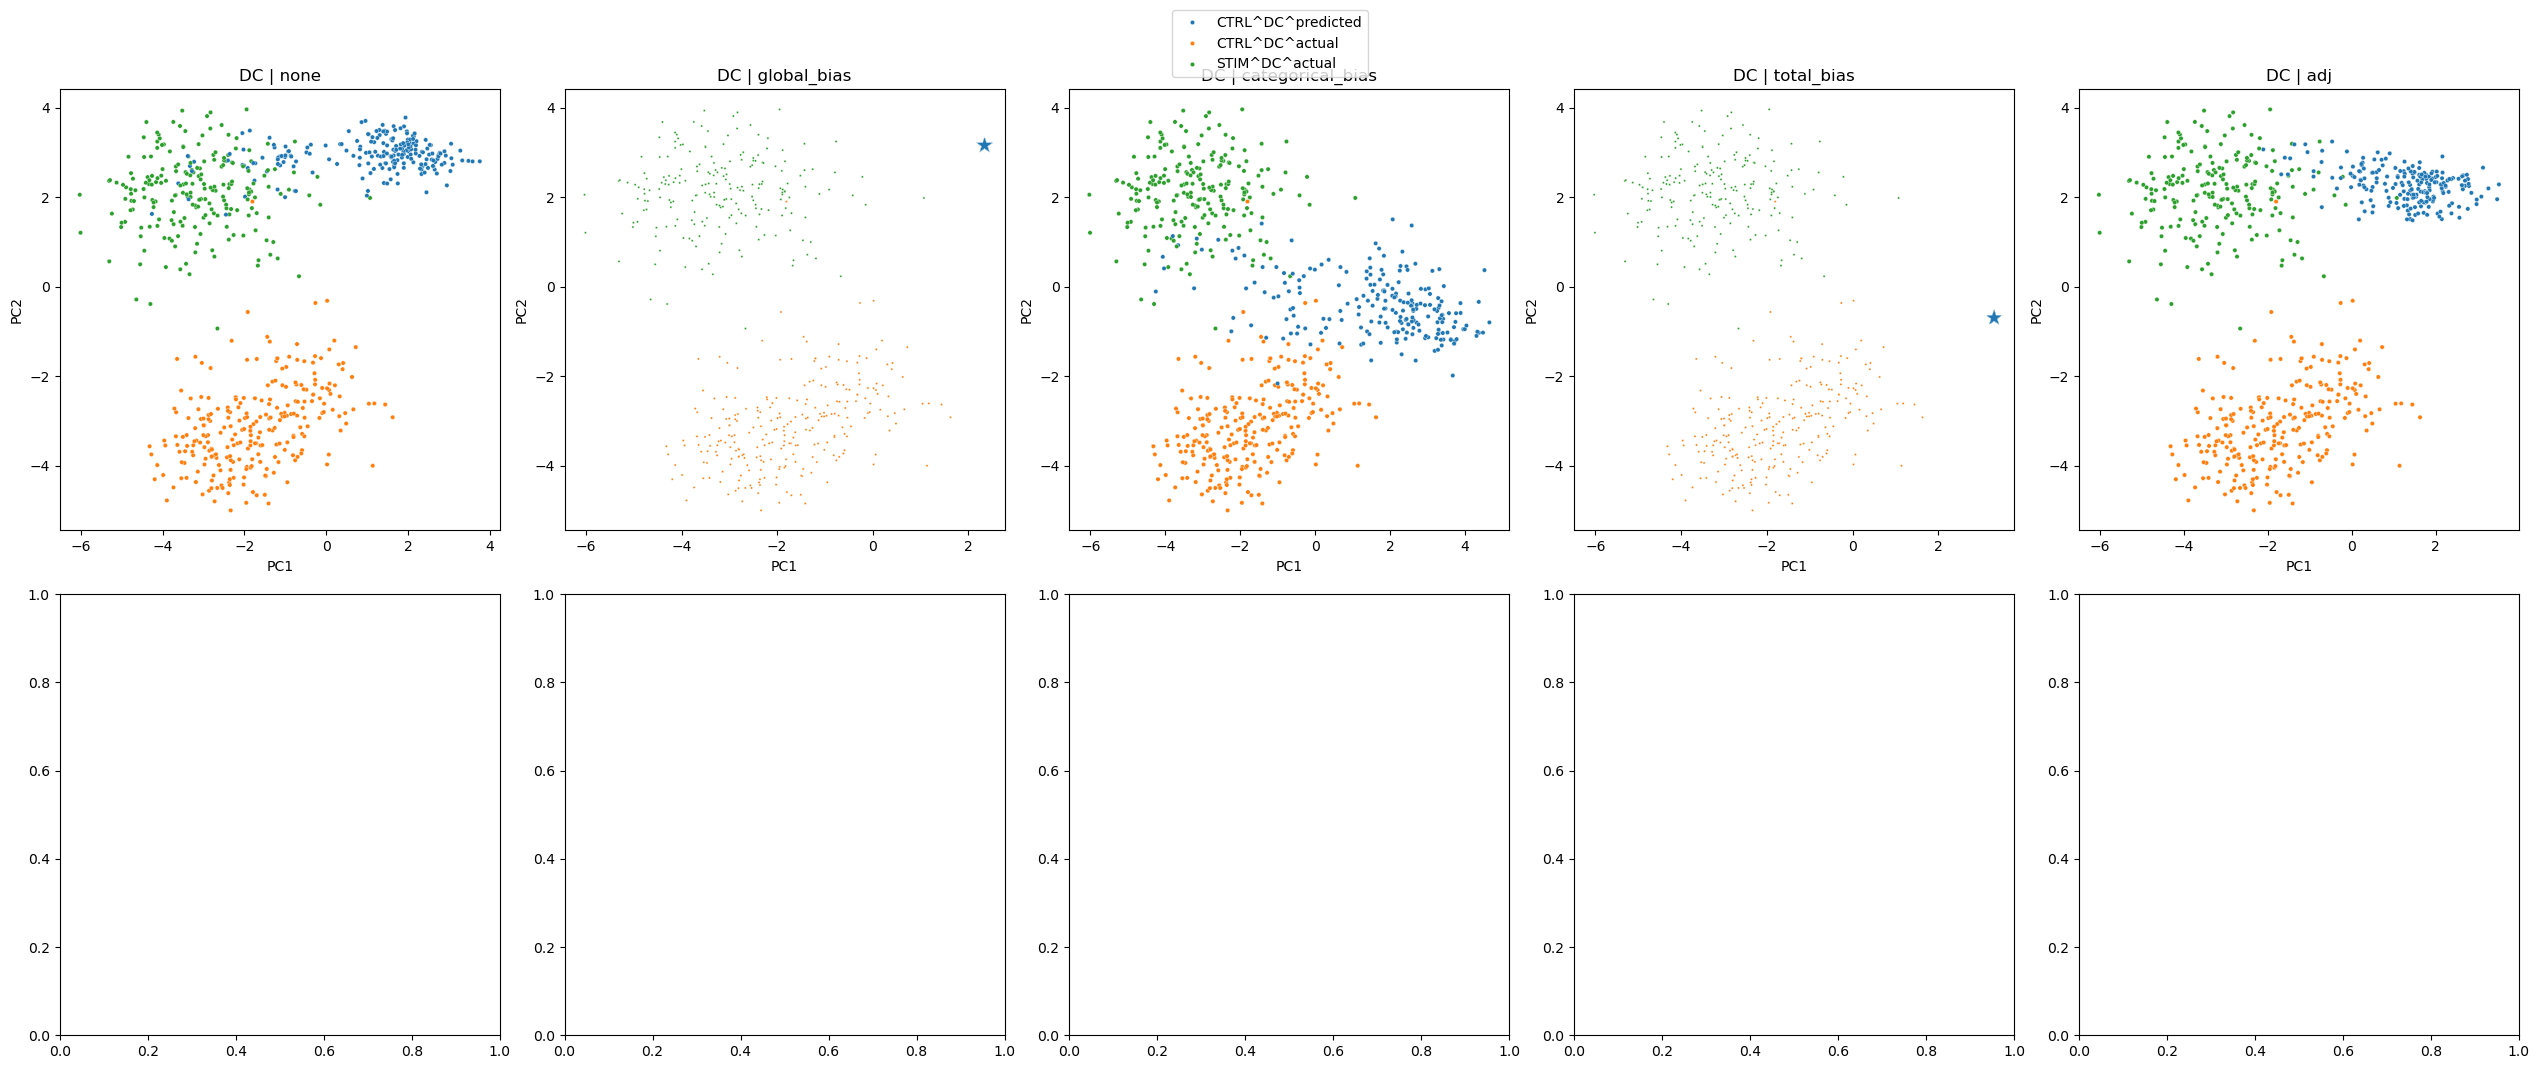

In [39]:
fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

for j, remove_component in enumerate(remove_components):
    
    tf_res = tf_res_.copy()
    tf_adata_all = tf_res[remove_component]
    
    tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

    tf_adata_viz = tf_adata_viz.copy()  
    tf_adata_viz.obs['condition'] = (
        tf_adata_viz.obs['stim'] + '^' + 
        tf_adata_viz.obs['seurat_annotations'] + '^' + 
        tf_adata_viz.obs['batch']
    )

    np.random.seed(seed)
    tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

    viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca',
                                     cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                     max_condition_size = None if counterfactual_type == 'opposite' else 3000,
                                     seed = seed)
    viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                              categories = cell_types, ordered=True)


    for i, cell_type in enumerate(cell_types):
        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

        stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
        order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                stim_pred + '^' + cell_type + '^' + 'actual', 
                rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
        viz_df_ = viz_df_.copy()
        viz_df_.condition = pd.Categorical(viz_df_.condition, 
                                              categories = order, ordered=True)

        np.random.seed(seed)
        viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]
        
        if i == 0 and j == 0:
            legend = True
        else: 
            legend = False
        
        if remove_component in ['global_bias', 'total_bias']:
            sns.scatterplot(data = viz_df_, x = 'PC1', y = 'PC2', hue = 'condition',
                            size = 'batch', sizes={"actual": 10, "predicted": 150}, 
                            style = 'batch', markers={"actual": '.', "predicted": '*'}, 
                            ax = axes[i, j], legend = legend)
        else:
            sns.scatterplot(data = viz_df_, x = 'PC1', y = 'PC2', hue = 'condition', 
                    s=10, ax = axes[i, j], legend = legend)
        axes[i,j].set_title(cell_type + ' | ' + remove_component)
        
        
        if i == 0 and j == 0:
            legend_actual = axes[i,j].legend_  # Store the legend
            axes[i,j].legend_.remove() 
            
fig.legend(handles=legend_actual.legendHandles, 
           labels=[t.get_text() for t in legend_actual.get_texts()], 
           loc="upper center", bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
# plt.savefig(os.path.join(data_path, 'trash', fn + '_loss_components_pca' + '.png'), dpi=300, bbox_inches='tight')

;


## 7.3 Visualize first 3 PCs of full model

In [40]:
tf_res = io.read_pickled_object(os.path.join(data_path, 'trash', fn + '_predictions.pickle'))
tf_adata_all = tf_res['none']

In [41]:
n_pcs = 3

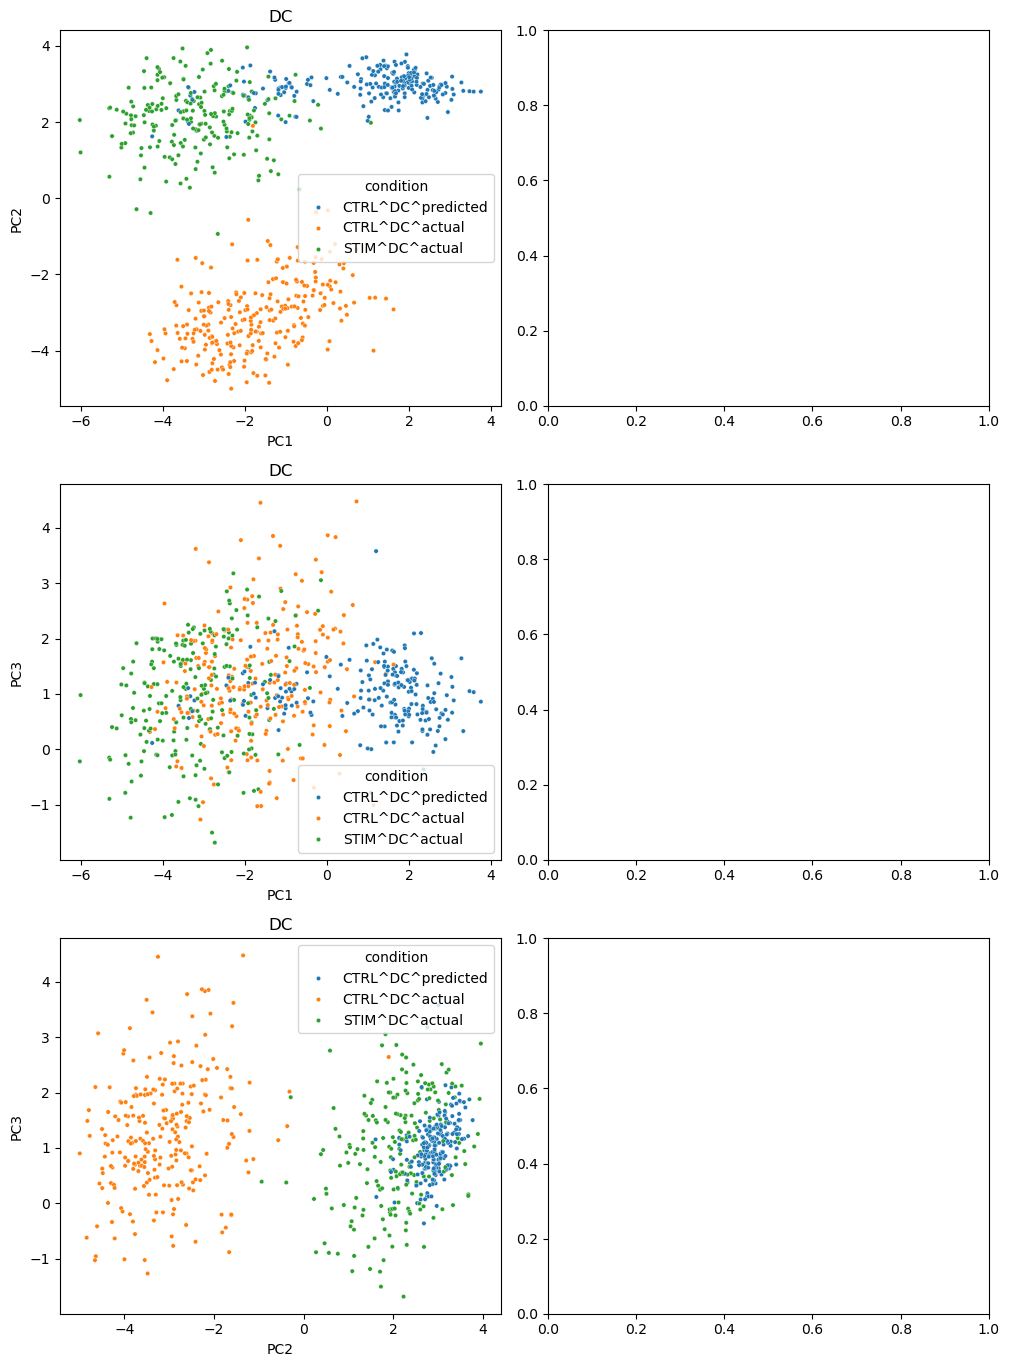

In [42]:
pc_combs = list(itertools.combinations(range(1, n_pcs + 1), 2))

ncols = max(2, len(test_conds))
nrows = len(pc_combs)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))

cell_types = [tc.split('^')[1] for tc in test_conds]

tf_adata_viz = tf_adata_all[tf_adata_all.obs[tf_adata_all.obs.seurat_annotations.isin(cell_types)].index.tolist(),:].copy()

tf_adata_viz = tf_adata_viz.copy()  
tf_adata_viz.obs['condition'] = (
    tf_adata_viz.obs['stim'] + '^' + 
    tf_adata_viz.obs['seurat_annotations'] + '^' + 
    tf_adata_viz.obs['batch']
)

np.random.seed(seed)
tf_adata_viz = tf_adata_viz[np.random.permutation(tf_adata_viz.obs_names), :]

viz_df = adata_dimviz_prediction(adata = tf_adata_viz, reduction_type = 'pca', 
                                 cats = ['seurat_annotations', 'batch', 'stim', 'condition'],
                                 max_condition_size = None if counterfactual_type == 'opposite' else 1000, 
                         seed = seed)
viz_df.seurat_annotations = pd.Categorical(viz_df.seurat_annotations, 
                                          categories = cell_types, ordered=True)


for j, cell_type in enumerate(cell_types):
    for i, comb in enumerate(pc_combs):
#         print(comb)
        viz_df_ = viz_df[viz_df.seurat_annotations == cell_type]

        stim_pred = viz_df_[viz_df_.batch == 'predicted'].stim.iloc[0]
        order = [stim_pred + '^' + cell_type + '^' + 'predicted', 
                stim_pred + '^' + cell_type + '^' + 'actual', 
                rev_stim[stim_pred] + '^' + cell_type + '^' + 'actual']
        viz_df_ = viz_df_.copy()
        viz_df_.condition = pd.Categorical(viz_df_.condition, 
                                              categories = order, ordered=True)

        np.random.seed(seed)
        viz_df_ = viz_df_.loc[np.random.permutation(viz_df_.index),:]
        sns.scatterplot(data = viz_df_, 
                        x = 'PC{}'.format(comb[0]), 
                        y = 'PC{}'.format(comb[1]), 
                        hue = 'condition', 
                s=10, ax = ax[i,j])
        ax[i,j].set_title(cell_type)

# fig.text(0.5, title_coords[i], 
#          counterfactual_type_title[counterfactual_type], 
#          ha='center', va='center', fontsize=18, fontweight='bold')

fig.tight_layout(rect=[0,0,1,0.9])
# plt.savefig(os.path.join(data_path, 'trash', fn + '_pca_main' + '.png'), dpi=300, bbox_inches='tight')

Clear variables:

In [43]:
import gc
gc.collect()
torch.cuda.empty_cache()  # Clears the cached memory
torch.cuda.ipc_collect()  # Collects unused memory blocks
